In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [3]:
def plotData(X,y):
    plt.figure
    plt.plot(X[np.where(y==1),0],X[np.where(y==1),1],'k+',linewidth = 2,markersize=7)
    plt.plot(X[np.where(y==0),0],X[np.where(y==0),1],'ko',markerfacecolor = 'y',markersize=7)
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend('Admitted', 'Not admitted')
    plt.show()

In [4]:
def sigmoid(z):
    g = np.zeros(z.shape)
    g = 1/(1+np.exp(-z))
    return g

In [5]:
def costFunction(theta,X,y):
    m = len(y)
    J = 0
    grad = np.zeros(theta.shape)
    h = sigmoid(X@theta)
    print(theta)
    #plt.figure()
    #plt.scatter(range(0,100),h)
    J = 1/m*(-y.T@np.log(h)-(1-y).T@np.log(1-h))
    grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))
    grad[1:] = 1/m*(X[:,1:].T@(h-y))
    return J, grad

   exam1_score  exam2_score  admission_status
0    34.623660    78.024693                 0
1    30.286711    43.894998                 0
2    35.847409    72.902198                 0
3    60.182599    86.308552                 1
4    79.032736    75.344376                 1


C:\Users\thein\AppData\Local\Temp\ipykernel_3184\2095019850.py:7: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Admitted', 'Not admitted')


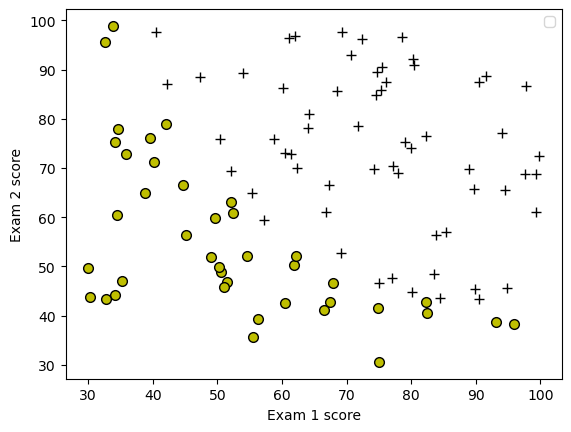

In [9]:
df = pd.read_csv('ex2data1.csv')
df.head()
print(df.head())
X= np.array(df[["exam1_score","exam2_score"]].values)
y = np.array(df["admission_status"].values,ndmin=2).reshape(-1).T
plotData(X,y)

In [10]:
m,n = X.shape
X = np.concatenate((np.ones((m,1)),X),axis=1)
theta_ini = np.zeros((n+1))

cost,grad = costFunction(theta_ini, X, y)

[0. 0. 0.]


C:\Users\thein\AppData\Local\Temp\ipykernel_3184\2312861754.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))


In [13]:
# Call minimize function with the objective function and initial guess
result = minimize(costFunction, theta_ini,args=(X,y), method='L-BFGS-B')

# Extract the optimal solution
optimal_solution = result.x

print("Optimal solution:", optimal_solution)
print("Minimum value:", result.fun)

[0. 0. 0.]


C:\Users\thein\AppData\Local\Temp\ipykernel_3184\2312861754.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))


ValueError: The user-provided objective function must return a scalar value.